In [1]:
from paritymatchingbsboardgames import *
from stim_bs_boardgames import *
import stim

# Dynamic Schedule w/ Pymatching

In [2]:
circuit = stim.Circuit.from_file('../circuits/yerrorbias5/5_0.001_y.stim')

In [2]:
import stim
import sinter
import matplotlib.pyplot as plt
import numpy as np
import multiprocessing
import glob
import os
from stim_bs_boardgames import *
import sys
sys.path.append("..") 

from sinter_file import *

In [16]:
# 1. Setup folders and collect tasks
folders = ["../circuits/yerrorbias5", "../circuits/yerrorbias7", "../circuits/yerrorbias9"]
all_tasks = []

for folder in folders:
    # Identify the bias from the folder name (e.g., '5', '7', or '9')
    bias_label = folder.split('yerrorbias')[-1]
    
    file_pattern = os.path.join(folder, "*.stim")
    for filepath in glob.glob(file_pattern):
        filename = os.path.basename(filepath)
        parts = filename.split('_')
        try:
            d = int(parts[0])      
            p = float(parts[1])   
            circuit = stim.Circuit.from_file(filepath)
                
            all_tasks.append(sinter.Task(
                circuit=circuit,
                json_metadata={'d': d, 'p': p, 'bias': bias_label,'filename': filename}
            ))
        except (IndexError, ValueError):
            print(f"Skipping {filename}")

# 2. Run the simulation
stats = sinter.collect(
    num_workers=multiprocessing.cpu_count(),
    tasks=all_tasks,
    decoders=['pymatching'],
    max_errors=1000,       
    max_shots=100_000_000, 
    print_progress=True,
)



Starting 12 workers...


19 tasks left:
  workers    decoder eta shots_left errors_left json_metadata                                 
        1 pymatching <1m   99997679         990 d=5,p=0.001,bias=5,filename=5_0.001_y.stim    
        1 pymatching   ?  100000000        1000 d=5,p=0.001,bias=5,filename=5_0.001_ytest.stim
        1 pymatching   ?  100000000        1000 d=5,p=0.003,bias=5,filename=5_0.003_y.stim    
        1 pymatching   ?  100000000        1000 d=5,p=0.005,bias=5,filename=5_0.005_y.stim    
        1 pymatching   ?  100000000        1000 d=5,p=0.002,bias=5,filename=5_0.002_y.stim    
        1 pymatching   ?  100000000        1000 d=5,p=0.006,bias=5,filename=5_0.006_y.stim    
        1 pymatching   ?  100000000        1000 d=5,p=0.004,bias=5,filename=5_0.004_y.stim    
        1 pymatching   ?  100000000        1000 d=7,p=0.004,bias=7,filename=7_0.004_y.stim    
        1 pymatching   ?  100000000        1000 d=7,p=0.006,bias=7,filename=7_0.006_y.stim    
        1 pymatching   ?  100000000

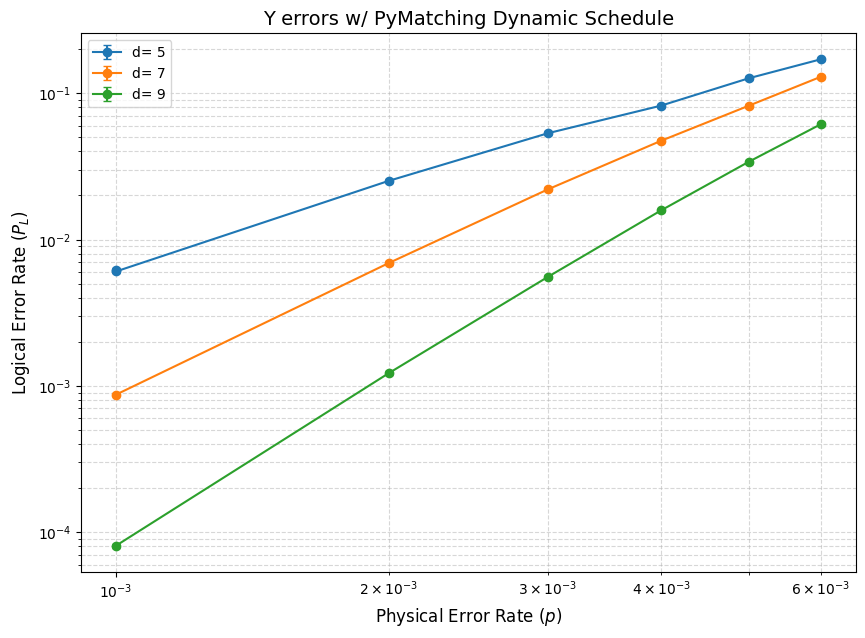

In [17]:
# 3. Plotting directly
plt.figure(figsize=(10, 7))

# We group by 'bias' to get one line per folder
biases = sorted(list(set(s.json_metadata['bias'] for s in stats)))

for b in biases:
    # Filter stats for this specific bias
    sub_stats = [s for s in stats if s.json_metadata['bias'] == b]
    
    # Extract x (physical p) and y (logical L)
    xs = [s.json_metadata['p'] for s in sub_stats]
    ys = [s.errors / s.shots for s in sub_stats]
    
    # Calculate standard deviation for error bars
    # formula: sqrt(p(1-p)/n)
    yerr = [np.sqrt((y * (1 - y)) / s.shots) if s.shots > 0 else 0 for y, s in zip(ys, sub_stats)]
    
    # Sort by x so the lines don't zig-zag
    order = np.argsort(xs)
    xs = np.array(xs)[order]
    ys = np.array(ys)[order]
    yerr = np.array(yerr)[order]
    
    plt.errorbar(xs, ys, yerr=yerr, fmt='o-', capsize=3, label=f"d= {b}")

# Formatting the plot
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Physical Error Rate ($p$)", fontsize=12)
plt.ylabel("Logical Error Rate ($P_L$)", fontsize=12)
plt.title("Y errors w/ PyMatching Dynamic Schedule", fontsize=14)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.show()

In [6]:
# 1. Setup folders and collect tasks
folders = ["../circuits/zerrorbias5", "../circuits/zerrorbias7", "../circuits/zerrorbias9"]
all_tasks = []

for folder in folders:
    # Identify the bias from the folder name (e.g., '5', '7', or '9')
    bias_label = folder.split('zerrorbias')[-1]
    
    file_pattern = os.path.join(folder, "*.stim")
    for filepath in glob.glob(file_pattern):
        filename = os.path.basename(filepath)
        parts = filename.split('_')
        try:
            d = int(parts[0])      
            p = float(parts[1])   
            circuit = stim.Circuit.from_file(filepath)
                
            all_tasks.append(sinter.Task(
                circuit=circuit,
                json_metadata={'d': d, 'p': p, 'bias': bias_label,'filename': filename}
            ))
        except (IndexError, ValueError):
            print(f"Skipping {filename}")

# 2. Run the simulation
stats = sinter.collect(
    num_workers=multiprocessing.cpu_count(),
    tasks=all_tasks,
    decoders=['pymatching'],
    max_errors=1000,       
    max_shots=100_000_000, 
    print_progress=True,
)



Starting 12 workers...
18 tasks left:
  workers    decoder eta shots_left errors_left json_metadata                             
        1 pymatching   ?  100000000        1000 d=5,p=0.004,bias=5,filename=5_0.004_z.stim
        1 pymatching   ?  100000000        1000 d=5,p=0.006,bias=5,filename=5_0.006_z.stim
        1 pymatching   ?  100000000        1000 d=5,p=0.002,bias=5,filename=5_0.002_z.stim
        1 pymatching   ?  100000000        1000 d=5,p=0.005,bias=5,filename=5_0.005_z.stim
        1 pymatching <1m   99997679         972 d=5,p=0.003,bias=5,filename=5_0.003_z.stim
        1 pymatching   ?  100000000        1000 d=5,p=0.001,bias=5,filename=5_0.001_z.stim
        1 pymatching   ?  100000000        1000 d=7,p=0.001,bias=7,filename=7_0.001_z.stim
        1 pymatching   ?  100000000        1000 d=7,p=0.003,bias=7,filename=7_0.003_z.stim
        1 pymatching   ?  100000000        1000 d=7,p=0.005,bias=7,filename=7_0.005_z.stim
        1 pymatching   ?  100000000        1000 d=7,

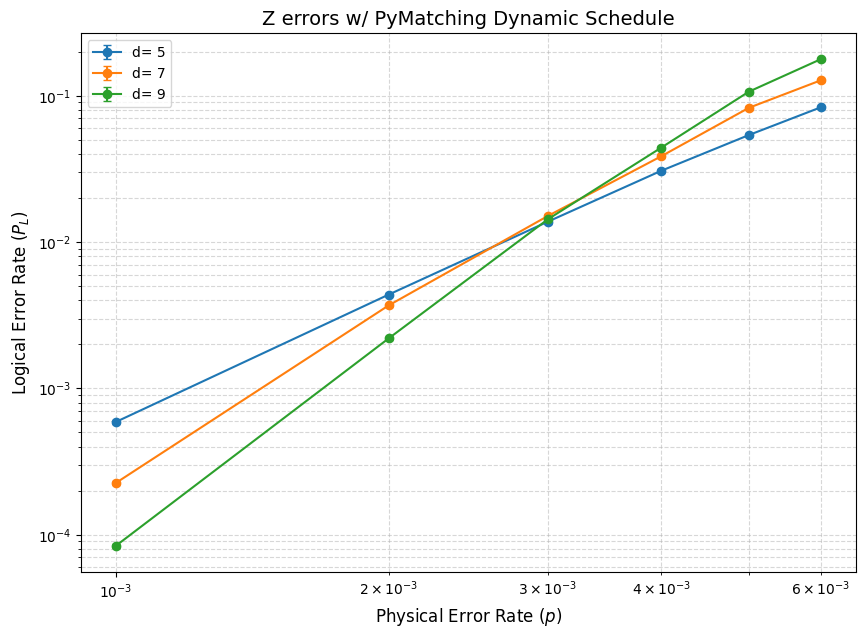

In [7]:
# 3. Plotting directly
plt.figure(figsize=(10, 7))

# We group by 'bias' to get one line per folder
biases = sorted(list(set(s.json_metadata['bias'] for s in stats)))

for b in biases:
    # Filter stats for this specific bias
    sub_stats = [s for s in stats if s.json_metadata['bias'] == b]
    
    # Extract x (physical p) and y (logical L)
    xs = [s.json_metadata['p'] for s in sub_stats]
    ys = [s.errors / s.shots for s in sub_stats]
    
    # Calculate standard deviation for error bars
    # formula: sqrt(p(1-p)/n)
    yerr = [np.sqrt((y * (1 - y)) / s.shots) if s.shots > 0 else 0 for y, s in zip(ys, sub_stats)]
    
    # Sort by x so the lines don't zig-zag
    order = np.argsort(xs)
    xs = np.array(xs)[order]
    ys = np.array(ys)[order]
    yerr = np.array(yerr)[order]
    
    plt.errorbar(xs, ys, yerr=yerr, fmt='o-', capsize=3, label=f"d= {b}")

# Formatting the plot
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Physical Error Rate ($p$)", fontsize=12)
plt.ylabel("Logical Error Rate ($P_L$)", fontsize=12)
plt.title("Z errors w/ PyMatching Dynamic Schedule", fontsize=14)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.show()

In [30]:
# 1. Setup folders and collect tasks
folders = ["../circuits/depolerror5", "../circuits/depolerror7", "../circuits/depolerror9"]
all_tasks = []

for folder in folders:
    # Identify the bias from the folder name (e.g., '5', '7', or '9')
    bias_label = folder.split('depolerror')[-1]
    
    file_pattern = os.path.join(folder, "*.stim")
    for filepath in glob.glob(file_pattern):
        filename = os.path.basename(filepath)
        parts = filename.split('_')
        try:
            d = int(parts[0])      
            p = float(parts[1])   
            circuit = stim.Circuit.from_file(filepath)
                
            all_tasks.append(sinter.Task(
                circuit=circuit,
                json_metadata={'d': d, 'p': p, 'bias': bias_label,'filename': filename}
            ))
        except (IndexError, ValueError):
            print(f"Skipping {filename}")

# 2. Run the simulation
stats = sinter.collect(
    num_workers=multiprocessing.cpu_count(),
    tasks=all_tasks,
    decoders=['pymatching'],
    max_errors=1000,       
    max_shots=100_000_000, 
    print_progress=True,
)



Starting 12 workers...
18 tasks left:
  workers    decoder eta shots_left errors_left json_metadata                                 
        1 pymatching   ?  100000000        1000 d=5,p=0.005,bias=5,filename=5_0.005_depol.stim
        1 pymatching   ?  100000000        1000 d=5,p=0.002,bias=5,filename=5_0.002_depol.stim
        1 pymatching   ?  100000000        1000 d=5,p=0.001,bias=5,filename=5_0.001_depol.stim
        1 pymatching   ?  100000000        1000 d=5,p=0.004,bias=5,filename=5_0.004_depol.stim
        1 pymatching <1m   99998703         896 d=5,p=0.003,bias=5,filename=5_0.003_depol.stim
        1 pymatching   ?  100000000        1000 d=5,p=0.006,bias=5,filename=5_0.006_depol.stim
        1 pymatching   ?  100000000        1000 d=7,p=0.001,bias=7,filename=7_0.001_depol.stim
        1 pymatching   ?  100000000        1000 d=7,p=0.004,bias=7,filename=7_0.004_depol.stim
        1 pymatching   ?  100000000        1000 d=7,p=0.003,bias=7,filename=7_0.003_depol.stim
        1 py

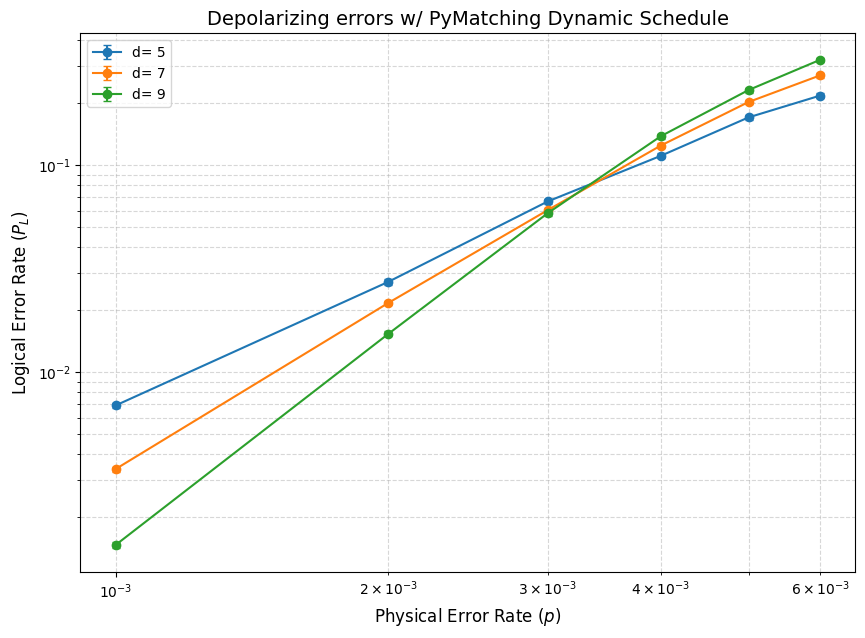

In [31]:
# 3. Plotting directly
plt.figure(figsize=(10, 7))

# We group by 'bias' to get one line per folder
biases = sorted(list(set(s.json_metadata['bias'] for s in stats)))

for b in biases:
    # Filter stats for this specific bias
    sub_stats = [s for s in stats if s.json_metadata['bias'] == b]
    
    # Extract x (physical p) and y (logical L)
    xs = [s.json_metadata['p'] for s in sub_stats]
    ys = [s.errors / s.shots for s in sub_stats]
    
    # Calculate standard deviation for error bars
    # formula: sqrt(p(1-p)/n)
    yerr = [np.sqrt((y * (1 - y)) / s.shots) if s.shots > 0 else 0 for y, s in zip(ys, sub_stats)]
    
    # Sort by x so the lines don't zig-zag
    order = np.argsort(xs)
    xs = np.array(xs)[order]
    ys = np.array(ys)[order]
    yerr = np.array(yerr)[order]
    
    plt.errorbar(xs, ys, yerr=yerr, fmt='o-', capsize=3, label=f"d= {b}")

# Formatting the plot
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Physical Error Rate ($p$)", fontsize=12)
plt.ylabel("Logical Error Rate ($P_L$)", fontsize=12)
plt.title("Depolarizing errors w/ PyMatching Dynamic Schedule", fontsize=14)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.show()

Starting 12 workers...
37 tasks left:
  workers    decoder eta shots_left errors_left json_metadata                                                  
        1 pymatching   ?  100000000        1000 d=5,p=0.005,bias=5,error_type=Depol,filename=5_0.005_depol.stim
        1 pymatching   ?  100000000        1000 d=5,p=0.002,bias=5,error_type=Depol,filename=5_0.002_depol.stim
        1 pymatching   ?  100000000        1000 d=5,p=0.001,bias=5,error_type=Depol,filename=5_0.001_depol.stim
        1 pymatching <1m   99998703         856 d=5,p=0.004,bias=5,error_type=Depol,filename=5_0.004_depol.stim
        1 pymatching   ?  100000000        1000 d=5,p=0.003,bias=5,error_type=Depol,filename=5_0.003_depol.stim
        1 pymatching   ?  100000000        1000 d=5,p=0.006,bias=5,error_type=Depol,filename=5_0.006_depol.stim
        1 pymatching   ?  100000000        1000 d=7,p=0.001,bias=7,error_type=Depol,filename=7_0.001_depol.stim
        1 pymatching   ?  100000000        1000 d=7,p=0.004,bias=7

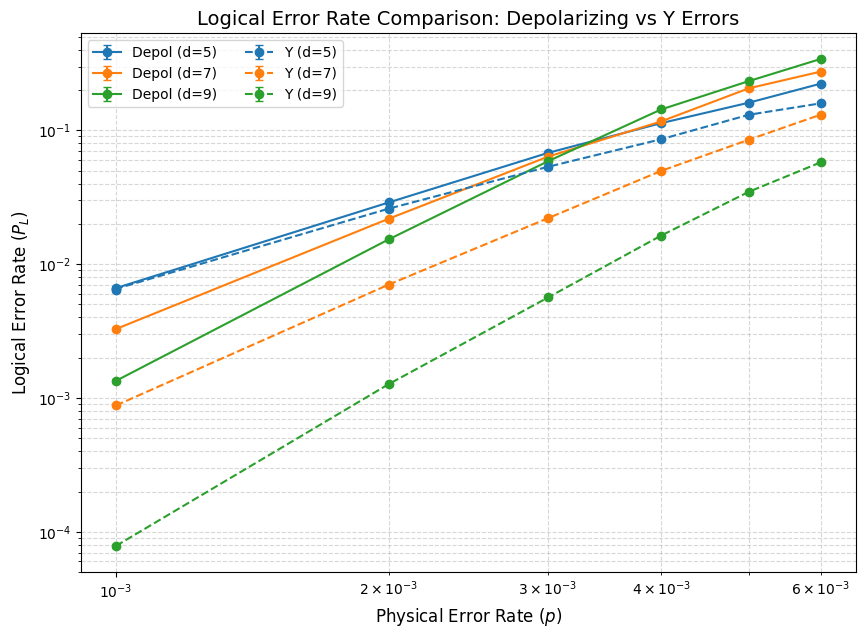

In [ ]:
import stim
import sinter
import multiprocessing
import os
import glob
import numpy as np
import matplotlib.pyplot as plt

# 1. Define groups and collect all tasks
groups = [
    {"folders": ["../circuits/depolerror5", "../circuits/depolerror7", "../circuits/depolerror9"], 
     "type": "Depol", "prefix": "depolerror"},
    {"folders": ["../circuits/yerrorbias5", "../circuits/yerrorbias7", "../circuits/yerrorbias9"], 
     "type": "Y", "prefix": "yerrorbias"}
]

all_tasks = []

for group in groups:
    for folder in group["folders"]:
        # Extract the distance label (e.g., '5')
        bias_label = folder.split(group["prefix"])[-1]
        
        file_pattern = os.path.join(folder, "*.stim")
        for filepath in glob.glob(file_pattern):
            filename = os.path.basename(filepath)
            parts = filename.split('_')
            try:
                d = int(parts[0])      
                p = float(parts[1])   
                circuit = stim.Circuit.from_file(filepath)
                
                all_tasks.append(sinter.Task(
                    circuit=circuit,
                    json_metadata={
                        'd': d, 
                        'p': p, 
                        'bias': bias_label, 
                        'error_type': group["type"],
                        'filename': filename
                    }
                ))
            except (IndexError, ValueError):
                continue

# 2. Run simulation once for all tasks
stats = sinter.collect(
    num_workers=multiprocessing.cpu_count(),
    tasks=all_tasks,
    decoders=['pymatching'],
    max_errors=1000,       
    max_shots=100_000_000, 
    print_progress=True,
)

# 3. Consolidated Plotting
plt.figure(figsize=(10, 7))

# Get unique combinations of error types and distances
error_types = ["Depol", "Y"]
distances = sorted(list(set(s.json_metadata['bias'] for s in stats)))

# Map distances to specific colors to keep d=5, 7, 9 consistent
color_map = {"5": "tab:blue", "7": "tab:orange", "9": "tab:green"}
# Map error types to line styles
style_map = {"Depol": "-", "Y": "--"}

for etype in error_types:
    for d in distances:
        # Filter for this specific combination
        sub_stats = [s for s in stats if s.json_metadata['error_type'] == etype and s.json_metadata['bias'] == d]
        
        if not sub_stats:
            continue
            
        xs = [s.json_metadata['p'] for s in sub_stats]
        ys = [s.errors / s.shots for s in sub_stats]
        yerr = [np.sqrt((y * (1 - y)) / s.shots) if s.shots > 0 else 0 for y, s in zip(ys, sub_stats)]
        
        # Sort data points for a smooth line
        order = np.argsort(xs)
        xs, ys, yerr = np.array(xs)[order], np.array(ys)[order], np.array(yerr)[order]
        
        # Plot with combined label and distinct style
        plt.errorbar(xs, ys, yerr=yerr, fmt='o', linestyle=style_map[etype], capsize=3, 
                     color=color_map.get(d), 
                     label=f"{etype} (d={d})")

# Formatting
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Physical Error Rate ($p$)", fontsize=12)
plt.ylabel("Logical Error Rate ($P_L$)", fontsize=12)
plt.title("Logical Error Rate Comparison: Depolarizing vs Y Errors", fontsize=14)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(ncol=2) # Use two columns for better label layout
plt.savefig("combined_error_plot.png")
plt.show()

In [12]:
import stim
import sinter
import multiprocessing
import os
import glob
import numpy as np
import matplotlib.pyplot as plt

# 1. Define groups and collect all tasks
groups = [
    {"folders": ["../circuits/zerrorbias5", "../circuits/zerrorbias7", "../circuits/zerrorbias9","../circuits/zerrorbias11","../circuits/zerrorbias13"], 
     "type": "Z", "prefix": "zerrorbias"},
    {"folders": ["../circuits/yerrorbias5", "../circuits/yerrorbias7", "../circuits/yerrorbias9", "../circuits/yerrorbias11","../circuits/yerrorbias13"], 
     "type": "Y", "prefix": "yerrorbias"}
]

all_tasks = []

for group in groups:
    for folder in group["folders"]:
        # Extract the distance label (e.g., '5')
        bias_label = folder.split(group["prefix"])[-1]
        
        file_pattern = os.path.join(folder, "*.stim")
        for filepath in glob.glob(file_pattern):
            filename = os.path.basename(filepath)
            parts = filename.split('_')
            try:
                d = int(parts[0])      
                p = float(parts[1])   
                circuit = stim.Circuit.from_file(filepath)
                
                all_tasks.append(sinter.Task(
                    circuit=circuit,
                    json_metadata={
                        'd': d, 
                        'p': p, 
                        'bias': bias_label, 
                        'error_type': group["type"],
                        'filename': filename
                    }
                ))
            except (IndexError, ValueError):
                continue

# 2. Run simulation once for all tasks
stats = sinter.collect(
    num_workers=multiprocessing.cpu_count(),
    tasks=all_tasks,
    decoders=['pymatching'],
    max_errors=1000,       
    max_shots=100_000_000, 
    print_progress=True,
)


Starting 12 workers...
61 tasks left:
  workers    decoder eta shots_left errors_left json_metadata                                              
        1 pymatching   ?  100000000        1000 d=5,p=0.004,bias=5,error_type=Z,filename=5_0.004_z.stim    
        1 pymatching   ?  100000000        1000 d=5,p=0.006,bias=5,error_type=Z,filename=5_0.006_z.stim    
        1 pymatching <1m   99996655         984 d=5,p=0.002,bias=5,error_type=Z,filename=5_0.002_z.stim    
        1 pymatching   ?  100000000        1000 d=5,p=0.005,bias=5,error_type=Z,filename=5_0.005_z.stim    
        1 pymatching   ?  100000000        1000 d=5,p=0.003,bias=5,error_type=Z,filename=5_0.003_z.stim    
        1 pymatching   ?  100000000        1000 d=5,p=0.001,bias=5,error_type=Z,filename=5_0.001_z.stim    
        1 pymatching   ?  100000000        1000 d=7,p=0.001,bias=7,error_type=Z,filename=7_0.001_z.stim    
        1 pymatching   ?  100000000        1000 d=7,p=0.003,bias=7,error_type=Z,filename=7_0.003_z

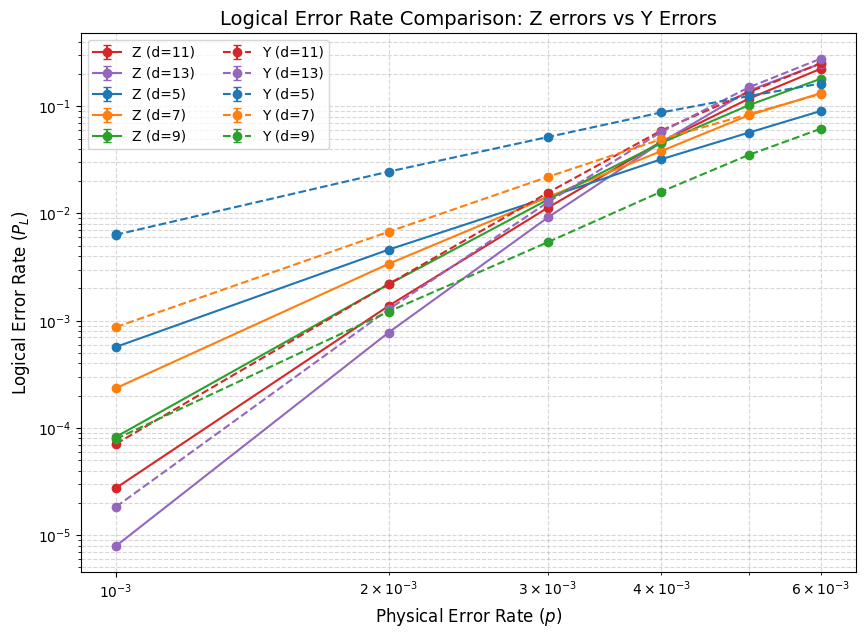

In [13]:

# 3. Consolidated Plotting
plt.figure(figsize=(10, 7))

# Get unique combinations of error types and distances
error_types = ["Z", "Y"]
distances = sorted(list(set(s.json_metadata['bias'] for s in stats)))

# Map distances to specific colors to keep d=5, 7, 9 consistent
color_map = {"5": "tab:blue", "7": "tab:orange", "9": "tab:green", "11": "tab:red", "13": "tab:purple"}
# Map error types to line styles
style_map = {"Z": "-", "Y": "--"}

for etype in error_types:
    for d in distances:
        # Filter for this specific combination
        sub_stats = [s for s in stats if s.json_metadata['error_type'] == etype and s.json_metadata['bias'] == d]
        
        if not sub_stats:
            continue
            
        xs = [s.json_metadata['p'] for s in sub_stats]
        ys = [s.errors / s.shots for s in sub_stats]
        yerr = [np.sqrt((y * (1 - y)) / s.shots) if s.shots > 0 else 0 for y, s in zip(ys, sub_stats)]
        
        # Sort data points for a smooth line
        order = np.argsort(xs)
        xs, ys, yerr = np.array(xs)[order], np.array(ys)[order], np.array(yerr)[order]
        
        # Plot with combined label and distinct style
        plt.errorbar(xs, ys, yerr=yerr, fmt='o', linestyle=style_map[etype], capsize=3, 
                     color=color_map.get(d), 
                     label=f"{etype} (d={d})")

# Formatting
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Physical Error Rate ($p$)", fontsize=12)
plt.ylabel("Logical Error Rate ($P_L$)", fontsize=12)
plt.title("Logical Error Rate Comparison: Z errors vs Y Errors", fontsize=14)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(ncol=2) # Use two columns for better label layout
plt.savefig("combined_error_plot.png")
plt.show()

In [22]:
print("\n--- RAW SIMULATION DATA ---")
print(f"{'Physical p':<12} | {'Errors':<10} | {'Shots':<12} | {'Logical L'}")
print("-" * 55)

for sample in collected_samples:
    p_phys = sample.json_metadata['p']
    errors = sample.errors
    shots = sample.shots
    # Calculate logical error rate
    p_log = errors / shots if shots > 0 else 0
    
    print(f"{p_phys:<12.6f} | {errors:<10} | {shots:<12} | {p_log:.2e}")

if all(s.errors == 0 for s in collected_samples):
    print("\n⚠️ WARNING: Every single task recorded 0 errors.")
    print("This is why your plot is blank—Log(0) cannot be plotted.")


--- RAW SIMULATION DATA ---
Physical p   | Errors     | Shots        | Logical L
-------------------------------------------------------
0.040000     | 0          | 100000000    | 0.00e+00
0.060000     | 0          | 100000000    | 0.00e+00
0.020000     | 0          | 100000000    | 0.00e+00
0.030000     | 0          | 100000000    | 0.00e+00
0.010000     | 0          | 100000000    | 0.00e+00
0.050000     | 0          | 100000000    | 0.00e+00

⚠️ WARNING: Every single task recorded 0 errors.
This is why your plot is blank—Log(0) cannot be plotted.


In [24]:

tasks = []
 
tasks.append(sinter.Task(
    circuit=stim.Circuit.from_file('../circuits/xerrorbias5high/5_0.01_x.stim'),
    
    json_metadata={'d': d, 'p': p}
))

collected_samples = sinter.collect(
        num_workers=multiprocessing.cpu_count(),
        tasks=tasks,
        decoders=['pymatching'],
        max_errors=1000,       
        max_shots=1_000_000_000, 
        print_progress=True,
    )
print("\n--- RAW SIMULATION DATA ---")
print(f"{'Physical p':<12} | {'Errors':<10} | {'Shots':<12} | {'Logical L'}")
print("-" * 55)

for sample in collected_samples:
    p_phys = sample.json_metadata['p']
    errors = sample.errors
    shots = sample.shots
    # Calculate logical error rate
    p_log = errors / shots if shots > 0 else 0
    
    print(f"{p_phys:<12.6f} | {errors:<10} | {shots:<12} | {p_log:.2e}")

if all(s.errors == 0 for s in collected_samples):
    print("\n⚠️ WARNING: Every single task recorded 0 errors.")
    print("This is why your plot is blank—Log(0) cannot be plotted.")
# sinter_plot(collected_samples, 5, "Using BS board game circuit files d = 5 x bias", True)

Starting 12 workers...
1 tasks left:
  workers    decoder eta shots_left errors_left json_metadata
       12 pymatching  5m  999997679        1000 d=5,p=0.02   
1 tasks left:
  workers    decoder eta shots_left errors_left json_metadata
       12 pymatching  4m  999746868        1000 d=5,p=0.02   
1 tasks left:
  workers    decoder eta shots_left errors_left json_metadata
       12 pymatching  4m  999323956        1000 d=5,p=0.02   
1 tasks left:
  workers    decoder eta shots_left errors_left json_metadata
       12 pymatching  4m  998979892        1000 d=5,p=0.02   
1 tasks left:
  workers    decoder eta shots_left errors_left json_metadata
       12 pymatching  4m  998532404        1000 d=5,p=0.02   
1 tasks left:
  workers    decoder eta shots_left errors_left json_metadata
       12 pymatching  4m  998330676        1000 d=5,p=0.02   
1 tasks left:
  workers    decoder eta shots_left errors_left json_metadata
       12 pymatching  4m  997842228        1000 d=5,p=0.02   
1 tasks lef


--- RAW SIMULATION DATA ---
Physical p   | Errors     | Shots        | Logical L
-------------------------------------------------------
0.020000     | 0          | 1000000000   | 0.00e+00

⚠️ WARNING: Every single task recorded 0 errors.
This is why your plot is blank—Log(0) cannot be plotted.
